# Less is More: Recursive Reasoning with Tiny Networks (https://arxiv.org/pdf/2510.04871)

**Alexia Jolicoeur-Martineau** (Samsung SAIL Montreal, 2025)

## Motiváció

A nagy nyelvi modellek (LLM-ek) auto-regresszív generálásuk miatt hajlamosak hibát elkövetni összetett feladatokon: egyetlen hibás token érvénytelenítheti a teljes választ. A megbízhatóság javítására két fő technikát alkalmaznak:

- **Chain-of-Thought (CoT):** az LLM lépésről lépésre gondolkodik a végső válasz előtt
- **Test-Time Compute (TTC):** K darab választ generálnak, és a leggyakoribbat / legjobb jutalmút adják vissza

Ezek sem elégségesek minden feladathoz. Az ARC-AGI benchmark (Chollet, 2019) máig megoldatlan emberi szinten. Az újabb ARC-AGI-2-n a Gemini 2.5 Pro is csupán 4.9%-ot ér el rengeteg TTC-vel.

**Alternatív irány:** Wang et al. (2025) bevezette a **Hierarchical Reasoning Model (HRM)**-t, amely rekurzív érvelés és mély szupervízió segítségével kis paraméterszámú modellekkel ér el kiemelkedő eredményeket puzzle-feladatokon.

**Ez a cikk** bemutatja a **Tiny Recursive Model (TRM)**-t, amely:
- egyszerűbb és matematikailag tisztább az HRM-nél
- egyetlen kis hálózatot (2 réteg, 7M paraméter) használ
- szignifikánsan jobb általánosítást ér el
- 45%-ot ér el ARC-AGI-1-en és 8%-ot ARC-AGI-2-n — a legtöbb LLM-nél jobbat a paraméterek töredékével (<0.01%)

## Háttér: Hierarchical Reasoning Model (HRM)

### Felépítés és cél

Az HRM felügyelt tanulási modell. Adott egy `[B, L]` alakú bemenet és kimenet (ahol B a batch-méret, L a kontexthossz). Az `[B, L, D]` alakú embedded reprezentációkon dolgozik.

Négy tanulható komponensből áll:
- `fI`: input embedding
- `fL`: alacsony szintű rekurrens hálózat (magas frekvenciájú)
- `fH`: magas szintű rekurrens hálózat (alacsony frekvenciájú)
- `fO`: output fej

Mindkét hálózat 4 rétegű Transformer architektúrát használ (RMSNorm, rotary embedding, SwiGLU aktiváció).

### Rekurzió két különböző frekvencián

Az HRM két látens jellemzőt tart fenn:
- `zL`: alacsony szintű látens jellemző (az `fL` outputja)
- `zH`: magas szintű látens jellemző (az `fH` outputja)

Egy előre pass (n=2, T=2 hyperparaméterekkel) így néz ki:

```
x  ← fI(x̃)
zL ← fL(zL + zH + x)   # gradiens nélkül
zL ← fL(zL + zH + x)   # gradiens nélkül
zH ← fH(zL + zH)        # gradiens nélkül
zL ← fL(zL + zH + x)   # gradiens nélkül
zL ← zL.detach()
zH ← zH.detach()
zL ← fL(zL + zH + x)   # gradiensekkel
zH ← fH(zL + zH)        # gradiensekkel
ŷ  ← argmax(fO(zH))
```

6 függvényhívásból csak az utolsó 2-n propagál a gradiens vissza.

### Fixpont-tétel és 1-lépéses gradiens-közelítés

Az HRM az **Implicit Function Theorem (IFT)** és az **1-lépéses gradiens-közelítés** segítségével igazolja, hogy elég csak az utolsó 2 lépésen visszapropagálni.

Az alap feltevés: ha `(zL, zH)` fixponthoz konvergál:
$$z^*_L \approx f_L(z^*_L + z_H + x)$$
$$z^*_H \approx f_H(z_L + z^*_H)$$

akkor az IFT szerint elegendő az egyensúlyi pontnál visszapropagálni egy lépést.

**Probléma:** nincs garancia arra, hogy fixpont valóban elérhető ilyen kevés iteráció után.

### Mély szupervízió (Deep Supervision)

A modell az előző lépés látens jellemzőit (`zH`, `zL`) viszi tovább a következő előre pass inicializálásához. Ezzel az effektív mélység növekszik anélkül, hogy az egész mélységen keresztül kellene visszapropagálni.

Legfeljebb `Nsup = 16` szupervíziós lépést alkalmaznak.

Az effektív mélység: `nlayers × (n+1) × T × Nsup = 4 × 3 × 2 × 16 = 384 réteg`.

### Adaptív számítási idő (ACT)

Az ACT egy korai leállási mechanizmus, amely megakadályozza, hogy a modell feleslegesen sok iterációt töltsön egyszerűbb adatpéldákon. Működése során a modell minden lépésben értékeli saját előrejelzésének minőségét: ha úgy ítéli meg, hogy a jelenlegi válasz már helyes, abbahagyja az iterálást és új adatpéldára lép. A HRM implementációban ez Q-learning alapon történik, ahol a modellnek egyszerre kell megtanulnia mikor érdemes megállni és mikor érdemes folytatni – utóbbihoz egy extra forward pass szükséges, ami megduplázza a számítási költséget. A TRM ezt leegyszerűsíti: csak a megállási feltételt tanulja egy egyszerű bináris osztályozóval, amely azt dönti el, elérte-e a modell a helyes megoldást. Ez elegendőnek bizonyul a hatékony korai leálláshoz, miközben a számítási igény felére csökken.

## HRM pszeudokód

In [ ]:
def hrm(z, x, n=2, T=2):
    zH, zL = z
    with torch.no_grad():
        for i in range(n * T - 2):
            zL = L_net(zL, zH, x)
            if (i + 1) % T == 0:
                zH = H_net(zH, zL)
    zL = L_net(zL, zH, x)
    zH = H_net(zH, zL)
    return (zH, zL), output_head(zH), Q_head(zH)


def ACT_halt(q, y_hat, y_true):
    target_halt = (y_hat == y_true)
    loss = 0.5 * binary_cross_entropy(q[0], target_halt)
    return loss


def ACT_continue(q, last_step):
    if last_step:
        target_continue = sigmoid(q[0])
    else:
        target_continue = sigmoid(max(q[0], q[1]))
    loss = 0.5 * binary_cross_entropy(q[1], target_continue)
    return loss



for x_input, y_true in train_dataloader:
    z = z_init
    for step in range(N_sup):
        x = input_embedding(x_input)
        z, y_pred, q = hrm(z, x)

        loss = softmax_cross_entropy(y_pred, y_true)
        loss += ACT_halt(q, y_pred, y_true)


        _, _, q_next = hrm(z, x)
        loss += ACT_continue(q_next, step == N_sup - 1)

        z = z.detach()
        loss.backward()
        opt.step()
        opt.zero_grad()

        if q[0] > q[1]:
            break

## Az HRM problémái

A szerzők három fő fejlesztési területet azonosítanak:

### 1. Az IFT és az 1-lépéses gradiens-közelítés problémái

Az HRM az IFT-re támaszkodik, ami megköveteli a fixpont elérését. Azonban:
- **Nincs garancia a fixpontra:** az HRM mindössze 4 rekurzión megy át, mielőtt feltételezi a konvergenciát, ez elégtelennek bizonyul
- A TRM cikk megemlíti, hogy a Wang et al. (2025) HRM-cikk 3. ábrája alapján, ahol n=7, T=7 esetét ábrázolják, a zH reziduuma jóval 0 fölött marad, és zL sem konvergál igazán a fixponthoz.
- A TRM megmutatja, hogy az IFT teljesen elkerülhető: **teljes rekurzión visszapropagál**, ami hatalmas (56.5% → 87.4%) javulást eredményez

### 2. Kétszeres előre pass az ACT-ban

Az ACT `continue loss`-a egy extra teljes előre passt igényel (6 függvényhívás). Így minden optimalizálási lépés 2× drágább. A TRM ezt egy egyszerűbb bináris keresztentrópia-veszteséggel helyettesíti, ami **1 előre passt igényel**, és szinte azonos eredményt ad.

### 3. Biológiai érvek és hierarchikus interpretáció

Az HRM két különböző hálózatot és biológiai érveket (egér-agykísérletek) használ az architekturális döntések igazolásához. Nehéz kideríteni, mi valójában hasznos és miért.

A TRM egy egyszerűbb, természetes értelmezést javasol:
- `zH` (→ `y`): az aktuális **megoldás**
- `zL` (→ `z`): **látens gondolkodási jellemző** (olyasmi, mint egy belső Chain-of-Thought)
- Pontosan 2 jellemzőre van szükség: `y` és `z` — sem több, sem kevesebb

## Tiny Recursive Model (TRM)

### Alapgondolat

A TRM egyetlen kis hálózatot (`net`) használ, amely rekurzívan javítja a látens gondolkodási jellemzőt (`z`), majd frissíti a megoldást (`y`).

```
Bemenet: x (kérdés), y (jelenlegi megoldás), z (látens)

Rekurzív gondolkodás (n lépés):
  z ← net(x, y, z)   # látens frissítése
  ...
  z ← net(x, y, z)

Megoldás frissítése:
  y ← net(y, z)       # x nélkül!
```

Fontos megfigyelés: a `z` frissítésekor az `x` is bemenet, a `y` frissítésekor nem. Ez elegendő ahhoz, hogy **egyetlen hálózat** elvégezze mindkét feladatot.

### Kulcskomponensek

#### 1. Teljes visszapropagálás (IFT nélkül)

Ahelyett, hogy fixpontot feltételezne és csak az utolsó 2 lépésen propagálna vissza, a TRM **visszapropagál az egész rekurzión** (n+1 lépésen). Ez eltávolítja az IFT-vel kapcsolatos elméleti problémákat.

**T-1 rekurzió** fut gradiens nélkül (hogy javítsa a látenseket), majd **1 rekurzió** fut gradiensekkel (a tanuláshoz).

#### 2. Egyetlen hálózat

Az `fL` és `fH` két különálló hálózat helyett **egy közös hálózatot** használ. Ez felezi a paraméterek számát, és jobb általánosítást eredményez.

#### 3. Kevesebb réteg = jobb általánosítás

Meglepő eredmény: 4 réteg helyett **2 réteg** jobb általánosítást ad kis adathalmazon. A kevesebb paraméter csökkenti a túlillesztés kockázatát, miközben a rekurzió biztosítja a szükséges "effektív mélységet".

Az effektív mélység: `T × (n+1) × nlayers = 3 × 7 × 2 = 42 réteg`

#### 4. MLP a self-attention helyett (kis, fix kontexthosszra)

Kis, fix méretű inputoknál (pl. 9×9 Sudoku) a self-attention helyett **MLP** alkalmazható a szekvencia hosszán. Ez jobb általánosítást ad Sudoku-ra, de nagy gridekre (30×30 Maze, ARC-AGI) a self-attention marad az optimális.

#### 5. Egyszerűsített ACT (1 előre pass)

A Q-learning alapú ACT helyett egy egyszerű **bináris keresztentrópia** alapú halting veszteséget alkalmaz:
```
loss += binary_cross_entropy(q_hat, (y_hat == y_true))
```
Nincs szükség a `continue loss`-ra és az extra előre passra.

#### 6. Exponenciális mozgóátlag (EMA)

Kis adathalmazon az HRM hajlamos gyorsan túlilleszkedni majd divergálni. Az **EMA** (0.999 decay) stabilizálja a tanítást és javítja az általánosítást (79.9% → 87.4%).

## TRM pszeudokód

In [ ]:
def latent_recursion(x, y, z, n=6):
    for i in range(n):
        z = net(x, y, z)
    y = net(y, z)
    return y, z


def deep_recursion(x, y, z, n=6, T=3):
    with torch.no_grad():
        for j in range(T - 1):
            y, z = latent_recursion(x, y, z, n)

    y, z = latent_recursion(x, y, z, n)
    return (y.detach(), z.detach()), output_head(y), Q_head(y)



for x_input, y_true in train_dataloader:
    y, z = y_init, z_init

    for step in range(N_supervision):
        x = input_embedding(x_input)
        (y, z), y_hat, q_hat = deep_recursion(x, y, z)

        loss = softmax_cross_entropy(y_hat, y_true)
        loss += binary_cross_entropy(q_hat, (y_hat == y_true))

        loss.backward()
        opt.step()
        opt.zero_grad()

        if q_hat > 0:
            break

## Összefoglalás

A TRM három egyszerű, de erőteljes elvből épül fel:

1. **Rekurzív gondolkodás:** egyetlen kis hálózat iteratívan javítja a látens állapotot (`z`) és a megoldást (`y`) — nincs szükség hierarchiára vagy biológiai érvekre
2. **Mély szupervízió:** a látens jellemzők átkerülnek a szupervíziós lépések között, effektíve nagyon mély hálózatot emulálva (anélkül, hogy végig kellene propagálni a gradienseket)
3. **Teljes visszapropagálás (IFT nélkül):** a gradiens végigmegy az egész rekurzión — ez a legfontosabb különbség az HRM-hez képest

**Kulcstanulság:** Kis adathalmazon a kisebb hálózat (2 réteg, 7M paraméter) + több rekurzió jobb általánosítást ad, mint a nagyobb hálózat + kevesebb rekurzió. A mélység emulálása rekurzióval hatékonyabb, mint valódi mélység paraméterekben.



##Model


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Eszköz: {device}")


Eszköz: cuda


In [ ]:
VOCAB_SIZE   = 10
SEQ_LEN      = 81
DIM          = 128
N_RECURSIONS = 1      # 6 cikk szerint
T            = 1      # 3 cikk szerint

N_EPOCHS     = 5000     #60000 cikkben
BATCH_SIZE   = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1.0
N_SUP         = 4
WARMUP_STEPS  = 200
EMA_DECAY     = 0.999

N_TRAIN = 200  # cikk: 1000
N_TEST  = 100


**Dataset**

In [ ]:
ds = load_dataset("sapientinc/sudoku-extreme")
ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/719M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/79.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3831994 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/422786 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['source', 'question', 'answer', 'rating'],
        num_rows: 3831994
    })
    test: Dataset({
        features: ['source', 'question', 'answer', 'rating'],
        num_rows: 422786
    })
})

In [ ]:
df_train = ds["train"].to_pandas().sample(N_TRAIN, random_state=42)
df_test  = ds["test"].to_pandas().sample(N_TEST,  random_state=42)

print(f"Training: {len(df_train)} példa")
print(f"Teszt:    {len(df_test)} példa")
print(f"Oszlopok: {df_train.columns}")
print(df_train.head(2))


Training: 200 példa
Teszt:    100 példa
Oszlopok: Index(['source', 'question', 'answer', 'rating'], dtype='object')
                              source  \
2047968  puzzles4_forum_hardest_1905   
3355892  puzzles4_forum_hardest_1905   

                                                  question  \
2047968  .5....7....3.8..9...926...4..8.1..6.........5....   
3355892  ...........86.4...57..8..6.85..6..3..9......2....   

                                                    answer  rating  
2047968  8529437164631875927192653842785149633967281451...      42  
3355892  4615237899286741535731892648542679311963485722...      53  


In [ ]:
class SudokuDataset(Dataset):
    def __init__(self, df):
        mapping = {'.':0,'1':1,'2':2,'3':3,'4':4,'5':5,'6':6,'7':7,'8':8,'9':9}
        self.x = [torch.tensor([mapping[c] for c in q if c in mapping]) for q in df['question']]
        self.y = [torch.tensor([mapping[c] for c in a if c in mapping]) for a in df['answer']]

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


In [ ]:
train_dataset = SudokuDataset(df_train)
test_dataset  = SudokuDataset(df_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

x, y = train_dataset[0]
print(f"x shape: {x.shape}, y shape: {y.shape}")
print(f"x min/max: {x.min()}/{x.max()}, y min/max: {y.min()}/{y.max()}")


x shape: torch.Size([81]), y shape: torch.Size([81])
x min/max: 0/9, y min/max: 1/9


In [ ]:
rms_norm = nn.RMSNorm(DIM) # ha van minimum 2.4 pytorch

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        norm = x.norm(dim=-1, keepdim=True) * (x.shape[-1] ** -0.5)
        return self.scale * x / (norm + self.eps)


In [ ]:
class SwiGLU(nn.Module):

    def __init__(self, dim):
        super().__init__()
        hidden = int(dim * 8 / 3)
        self.gate = nn.Linear(dim, hidden, bias=False)
        self.proj = nn.Linear(dim, hidden, bias=False)
        self.out  = nn.Linear(hidden, dim, bias=False)

    def forward(self, x):
        return self.out(F.silu(self.gate(x)) * self.proj(x))


In [ ]:
class SequenceMLP(nn.Module):
    def __init__(self, seq_len, dim):
        super().__init__()
        self.norm = RMSNorm(seq_len) # nn.RMSNorm(seq_len)
        self.mix  = nn.Linear(seq_len, seq_len, bias=False)

    def forward(self, x):
        xt = x.transpose(1, 2)
        xt = self.mix(self.norm(xt))
        return xt.transpose(1, 2)


In [ ]:
class TRMBlock(nn.Module):
    def __init__(self, dim, seq_len):
        super().__init__()
        self.norm1   = RMSNorm(dim) # nn.RMSNorm(dim)
        self.seq_mix = SequenceMLP(seq_len, dim)
        self.norm2   = RMSNorm(dim) # nn.RMSNorm(dim)
        self.mlp     = SwiGLU(dim)

    def forward(self, x):
        x = x + self.seq_mix(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


In [ ]:
class TinyRecursiveModel(nn.Module):
    def __init__(self, vocab_size, seq_len, dim, n_recursions, T):
        super().__init__()
        self.dim = dim
        self.n   = n_recursions
        self.T   = T
        self.norm_z = RMSNorm(dim)
        self.norm_y = RMSNorm(dim)

        self.input_emb  = nn.Embedding(vocab_size, dim)
        self.answer_emb = nn.Embedding(vocab_size, dim)


        self.net = nn.Sequential(
            TRMBlock(dim, seq_len),
            TRMBlock(dim, seq_len),
        )


        self.output_norm = RMSNorm(dim) # nn.RMSNorm(dim)
        self.output_head = nn.Linear(dim, vocab_size, bias=False)

        self.q_norm = RMSNorm(dim) # nn.RMSNorm(dim)
        self.q_head = nn.Linear(dim, 1, bias=False)

        self._init_weights()

    def _init_weights(self):
      for m in self.modules():
          if isinstance(m, nn.Linear):
              nn.init.normal_(m.weight, std=0.02 / (2 * self.n) ** 0.5)
          elif isinstance(m, nn.Embedding):
              nn.init.normal_(m.weight, std=0.02)

    def latent_recursion(self, x_emb, y, z):
      for _ in range(self.n):
          z = self.net(self.norm_z(x_emb + y + z))
      y = self.net(self.norm_y(y + z))
      return y, z

    def deep_recursion(self, x_emb, y, z):
        with torch.no_grad():
            for _ in range(self.T - 1):
                y, z = self.latent_recursion(x_emb, y, z)
        y, z = self.latent_recursion(x_emb, y, z)
        y_hat = self.output_head(self.output_norm(y))
        q_hat = self.q_head(self.q_norm(y)).squeeze(-1)
        return (y.detach(), z.detach()), y_hat, q_hat


In [ ]:
model = TinyRecursiveModel(
    vocab_size   = VOCAB_SIZE,
    seq_len      = SEQ_LEN,
    dim          = DIM,
    n_recursions = N_RECURSIONS,
    T            = T,
).to(device)

In [ ]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.model  = model
        self.decay  = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self):
        for k, v in self.model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply_shadow(self):
        self.model.load_state_dict(self.shadow)


In [ ]:
def train_trm(model, train_loader, n_epochs, lr, weight_decay, n_sup, warmup_steps, device):

    ema = EMA(model, decay=EMA_DECAY)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr,
        weight_decay=weight_decay, betas=(0.9, 0.95)
    )

    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps
    )

    model.train()
    global_step = 0

    for epoch in range(n_epochs):
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            B, L    = x_batch.shape

            y_prev = torch.zeros(B, L, model.dim, device=device)
            z_prev = torch.zeros(B, L, model.dim, device=device)
            total_loss, n_steps_done = 0.0, 0

            for step in range(n_sup):
                x_emb = model.input_emb(x_batch)
                (y_new, z_new), y_hat, q_hat = model.deep_recursion(x_emb, y_prev, z_prev)


                pred_loss = F.cross_entropy(
                    y_hat.reshape(-1, y_hat.shape[-1]),
                    y_batch.reshape(-1)
                )

                with torch.no_grad():
                    correct = (y_hat.argmax(-1) == y_batch).all(dim=-1).float()
                q_mean    = q_hat.mean(dim=-1)
                halt_loss = F.binary_cross_entropy_with_logits(q_mean, correct)

                loss = pred_loss + halt_loss
                total_loss   += loss.item()
                n_steps_done += 1

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                ema.update()

                if global_step < warmup_steps:
                    scheduler.step()
                global_step += 1

                y_prev, z_prev = y_new, z_new


                if q_mean.mean() > 0:
                    break

            if epoch % 500 == 0:
                print(f"Epoch {epoch:6d} | Loss: {total_loss/n_steps_done:.4f} | Steps: {n_steps_done}")

    return model, ema


In [ ]:

model, ema = train_trm(
    model        = model,
    train_loader = train_loader,
    n_epochs     = N_EPOCHS,
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY,
    n_sup        = N_SUP,
    warmup_steps = WARMUP_STEPS,
    device       = device,
)


Epoch      0 | Loss: 2.9350 | Steps: 4
Epoch      0 | Loss: 2.9359 | Steps: 4
Epoch      0 | Loss: 2.9321 | Steps: 4
Epoch      0 | Loss: 2.9312 | Steps: 4
Epoch      0 | Loss: 2.9269 | Steps: 4
Epoch      0 | Loss: 2.9217 | Steps: 4
Epoch      0 | Loss: 2.9180 | Steps: 4
Epoch    500 | Loss: 0.5418 | Steps: 2
Epoch    500 | Loss: 0.4216 | Steps: 2
Epoch    500 | Loss: 0.4144 | Steps: 2
Epoch    500 | Loss: 0.4440 | Steps: 2
Epoch    500 | Loss: 0.4971 | Steps: 2
Epoch    500 | Loss: 0.4155 | Steps: 2
Epoch    500 | Loss: 0.3990 | Steps: 2
Epoch   1000 | Loss: 0.5873 | Steps: 2
Epoch   1000 | Loss: 0.5129 | Steps: 2
Epoch   1000 | Loss: 0.5098 | Steps: 2
Epoch   1000 | Loss: 0.4618 | Steps: 2
Epoch   1000 | Loss: 0.5316 | Steps: 2
Epoch   1000 | Loss: 0.3829 | Steps: 2
Epoch   1000 | Loss: 0.4259 | Steps: 2
Epoch   1500 | Loss: 0.4087 | Steps: 1
Epoch   1500 | Loss: 0.4492 | Steps: 1
Epoch   1500 | Loss: 0.6204 | Steps: 1
Epoch   1500 | Loss: 0.4713 | Steps: 1
Epoch   1500 | Loss: 0.57

In [ ]:
@torch.no_grad()
def evaluate_token(model, test_loader, n_sup, device):
    model.eval()
    correct = 0
    total   = 0

    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        B, L    = x_batch.shape

        x_emb = model.input_emb(x_batch)
        y = torch.zeros(B, L, model.dim, device=device)
        z = torch.zeros(B, L, model.dim, device=device)

        for _ in range(n_sup):
            (y, z), y_hat, _ = model.deep_recursion(x_emb, y, z)

        preds   = y_hat.argmax(dim=-1)
        correct += (preds == y_batch).sum().item()
        total   += B * L

    return correct / total

acc_token = evaluate_token(model, test_loader, n_sup=N_SUP, device=device)
print(f"Token pontosság: {acc_token*100:.1f}%")

Token pontosság: 15.6%


##Kiértékelés

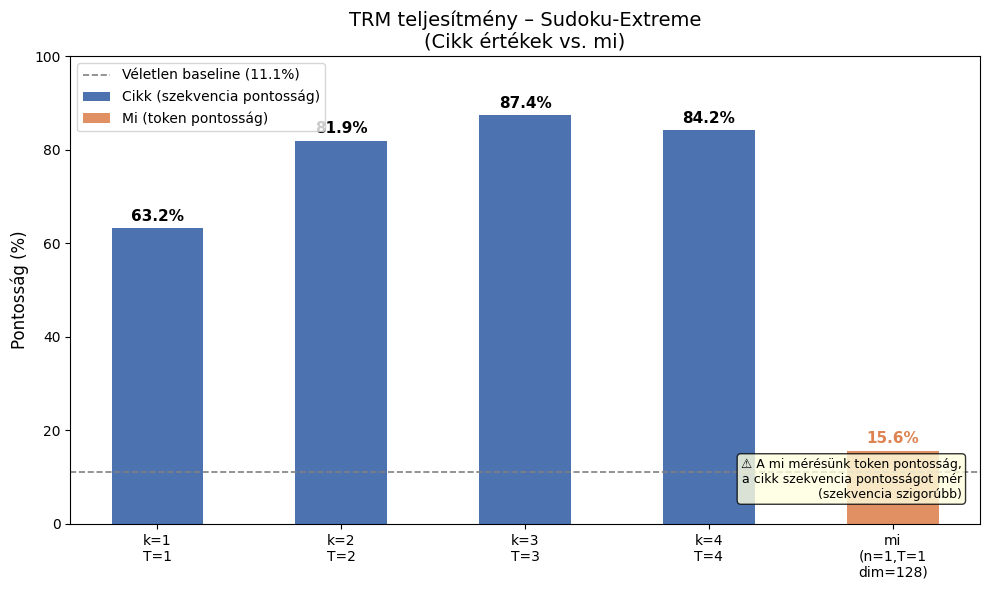

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


cikk_configs = ["k=1\nT=1", "k=2\nT=2", "k=3\nT=3", "k=4\nT=4"]
cikk_acc     = [63.2,       81.9,        87.4,        84.2      ]

mi_config = "mi\n(n=1,T=1\ndim=128)"
mi_acc    = 15.6



fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(cikk_configs))

bars = ax.bar(x, cikk_acc, width=0.5, color="#4C72B0", label="Cikk (szekvencia pontosság)")

ax.bar(len(cikk_configs), mi_acc, width=0.5, color="#DD8452",
       label="Mi (token pontosság)", alpha=0.9)

ax.axhline(y=11.1, color="gray", linestyle="--", linewidth=1.2, label="Véletlen baseline (11.1%)")

for i, v in enumerate(cikk_acc):
    ax.text(i, v + 1, f"{v}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.text(len(cikk_configs), mi_acc + 1, f"{mi_acc}%", ha="center",
        va="bottom", fontsize=11, fontweight="bold", color="#DD8452")

ax.set_xticks(list(x) + [len(cikk_configs)])
ax.set_xticklabels(cikk_configs + [mi_config], fontsize=10)
ax.set_ylabel("Pontosság (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_title("TRM teljesítmény – Sudoku-Extreme (Cikk értékek vs. mi)", fontsize=14)
ax.legend(fontsize=10)


ax.text(0.98, 0.05,
    "A mi mérésünk token pontosság,a cikk szekvencia pontosságot mér (szekvencia szigorúbb)",
    transform=ax.transAxes, fontsize=9, ha="right", va="bottom",
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()